$$
\providecommand{\bm}{\boldsymbol}
\providecommand{\R}{\mathbb{R}}
\providecommand{\xv}{\mathbf{x}}
\providecommand{\E}{\mathbb{E}}
\providecommand{\fh}{\hat{f}}
\providecommand{\sh}{\hat{s}}
\providecommand{\fmin}{f_{\min}}
\providecommand{\Dt}{\mathcal{D}^{[t]}}
$$

## Problem 1: Closed-form Expected Improvement

Derive the closed form expression of the **Expected Improvement** acquisition function:

$$a_{\text{EI}}(\xv) = \left(\fmin - \fh(\xv)\right)\, \Phi\!\left(\frac{\fmin - \fh(\xv)}{\sh(\xv)}\right) + \sh(\xv)\, \phi\!\left(\frac{\fmin - \fh(\xv)}{\sh(\xv)}\right).$$

Assume $Y(\xv) \sim \mathcal{N}(\fh(\xv), \sh^2(\xv))$.

*Hints:*

- Start from $a_{\text{EI}}(\xv) = \E_y[\max\{\fmin - y, 0\}] = \int \max\{\fmin - y, 0\}\, p(y)\, dy$.
- Decompose the integral by whether $y < \fmin$ or $y \geq \fmin$.
- Substitute $u = (y - \fh(\xv))/\sh(\xv)$.
- Use $\int_{-\infty}^z u\,\phi(u)\,du = -\phi(z)$.

**Solution.**

We start with

$$
a_{\text{EI}}(\xv) = \E_{y}(\max\{\fmin - y, 0\}) = \int_{-\infty}^{\infty} \max\{\fmin - y, 0\} p(y) dy.
$$

Observe that

$$\max\{\fmin - y, 0\} =
  \begin{cases}
    \fmin - y, & \text{if } y < \fmin,\\
    0,         & \text{otherwise}.
  \end{cases}
$$

All contributions for $y \ge \fmin$ are zero. Therefore, we can additively decompose the integral and it simplifies to

$$
a_{\text{EI}}(\xv) = \int_{-\infty}^{\fmin} \left(\fmin - y\right) p(y) dy.
$$

$$
\begin{aligned}
\alpha_{\text{EI}}(\xv) &= \int_{-\infty}^{\fmin}\left(\fmin -y\right) p(y) dy \\
    &= \int_{-\infty}^{\fmin}\left(\fmin - y\right) \frac{1}{\sqrt{2 \pi \sh(\xv)^2}} \exp \left(-\frac{\left(y-\fh(\xv)\right)^2}{2 \sh(\xv)^2}\right) d y\\
    &= \int_{-\infty}^{z}\left(\fmin-\fh(\xv)-u \sh(\xv)\right) \frac{1}{\sqrt{2 \pi \sh(\xv)^2}} \exp \left(-\frac{u^2}{2}\right)\sh(\xv) d u~\left(\text {Def. } u:=\frac{y-\fh(\xv)}{\sh(\xv)}, \frac{d u}{d y}=\frac{1}{\sh(\xv)}, z := \frac{\fmin-\fh(\xv)}{\sh(\xv)}\right) \\
    &= \int_{-\infty}^{z}\left(\fmin-\fh(\xv)-u \sh(\xv)\right) \phi(u) d u \\
    &= \int_{-\infty}^{z}\left(\fmin-\fh(\xv)\right) \phi(u) d u - \int_{-\infty}^{z}\left(u \sh(\xv)\right) \phi(u) d u
\end{aligned}
$$

Note that

$$
\Phi(z)=\int_{-\infty}^{z} \phi(u) d u
$$

by definition.

Therefore, regarding the first integral:

$$
\int_{-\infty}^{z}\left(\fmin-\fh(\xv)\right) \phi(u) d u = \left(\fmin - \fh(\xv)\right) \Phi(z) = z \sh(\xv) \Phi(z).
$$

Regarding the second integral we use the identity

$$
\int_{-\infty}^z u \phi(u) d u = - \phi(z).
$$

Putting both together we obtain:

$$
\begin{aligned}
\alpha_{\text{EI}}(\xv) &= z \sh(\xv) \Phi(z)-\sh(\xv)(-\phi(z)) \\
    &= z \sh(\xv) \Phi(z)+\sh(\xv) \phi(z)\\
    &= \left(\fmin - \fh(\xv)\right) \Phi\left(\frac{\fmin - \fh(\xv)}{\sh(\xv)}\right) + \sh(\xv) \phi\left(\frac{\fmin - \fh(\xv)}{\sh(\xv)}\right).
\end{aligned}
$$

## Problem 2: Implement Bayesian Optimization

Implement BO with a Gaussian-process surrogate and Expected Improvement acquisition. Goal: minimize

$$f: [0, 1] \to \R, \quad x \mapsto 2x\sin(14x).$$

Start with 4 points sampled uniformly at random and terminate after 10 total evaluations.

1. Write the BO loop in pseudocode.
2. Implement it. Optimize the EI via a univariate method (Brent's / `optimize`).

Let $\mathcal{D}$ be the initial design consisting of $(x^{[1]}, y^{[1]}), \ldots, (x^{[4]}, y^{[4]})$. Set $t$ to $4$.

While $t < 10$:

1. Fit surrogate model on $\mathcal{D}$.
2. Optimize the Expected Improvement $a_{\text{EI}}(x)$ to obtain a new point $x^{[t+1]} := \operatorname{arg\,max}_{x \in [0, 1]} a_{\text{EI}}(x)$.
3. Evaluate $x^{[t+1]}$ and update design data $\mathcal{D} = \mathcal{D} \cup \{(x^{[t+1]}, f(x^{[t+1]}))\}$.
4. Set $t$ to $t + 1$.

Return $x$ that minimizes $f(x)$ in $\mathcal{D}$: $\operatorname{arg\,min}_{(x, y) \in \mathcal{D}} y$.

Warning message:
"package 'DiceKriging' was built under R version 4.4.3"


Warning message:
"package 'patchwork' was built under R version 4.4.2"


BO best after 10 evals: x = 0.7854, f = -1.5708


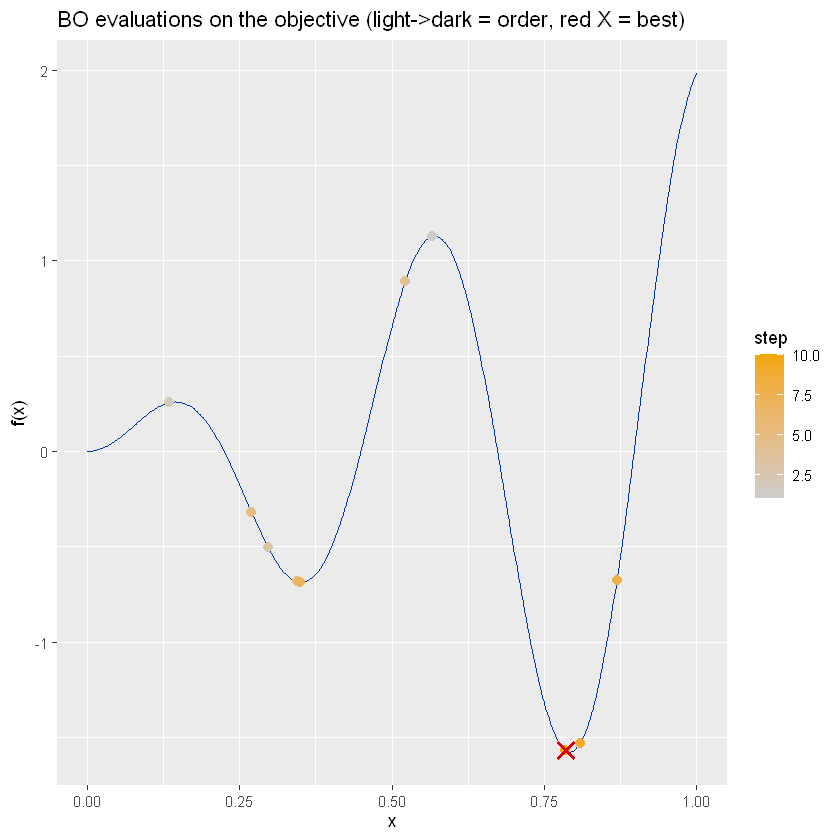

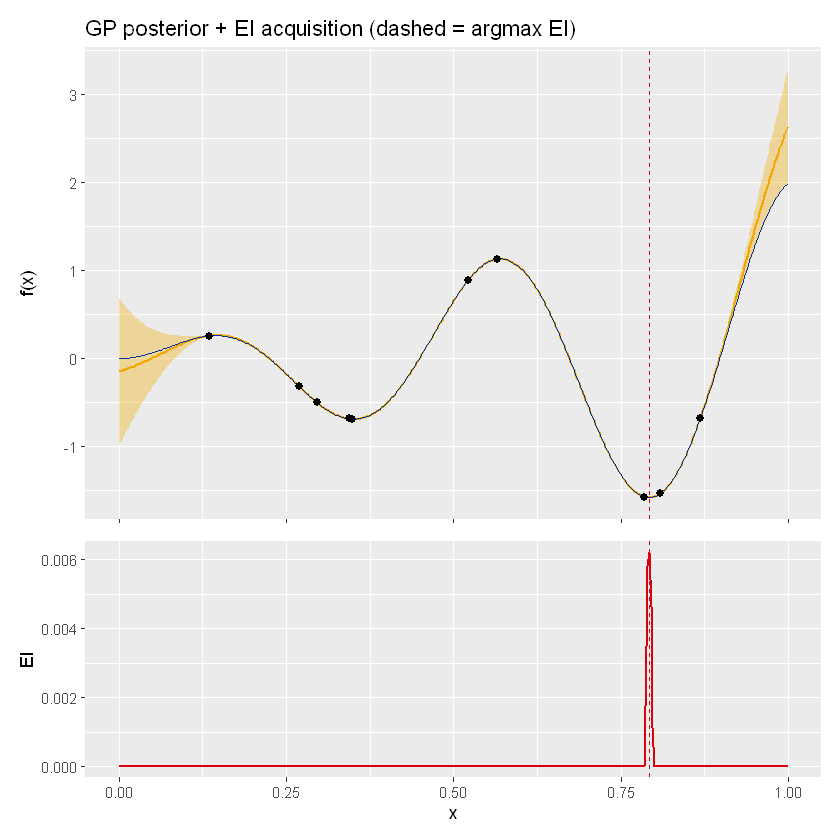

In [1]:
#| label: bo_loop
library(DiceKriging)
library(ggplot2)
library(patchwork)

set.seed(308)
f <- function(x) 2 * x * sin(14 * x)                  # objective

# Initial design: 4 random points in [0, 1]
initial_x <- runif(4)
design <- data.frame(x = initial_x, y = f(initial_x))
t <- 4

# Expected improvement using the closed form derived in problem 1.
ei <- function(x, current_fmin, current_gp) {
  pr <- predict(current_gp, newdata = data.frame(x = x), type = "SK")
  diff <- current_fmin - pr$mean
  z <- diff / pr$sd
  diff * pnorm(z) + pr$sd * dnorm(z)
}

while (t < 10) {
  gp <- km(design = design[, 1L, drop = FALSE], response = design[, 2L],
           covtype = "gauss", nugget = 1e-8, control = list(trace = FALSE))
  fmin <- min(design$y)
  x_new <- optimize(ei, interval = c(0, 1), maximum = TRUE,
                    current_fmin = fmin, current_gp = gp)$maximum
  design <- rbind(design, data.frame(x = x_new, y = f(x_new)))
  t <- t + 1
}

bo_best <- design[which.min(design$y), ]
cat(sprintf("BO best after 10 evals: x = %.4f, f = %+.4f\n",
            bo_best$x, bo_best$y))

# Objective with BO's evaluations (light -> dark = evaluation order)
x_grid <- seq(0, 1, length.out = 401)
df_curve <- data.frame(x = x_grid, y = f(x_grid))
df_design <- design
df_design$step <- seq_len(nrow(df_design))

ggplot() +
  geom_line(data = df_curve, aes(x, y), color = "#0033A0", linewidth = 0.5) +
  geom_point(data = df_design, aes(x, y, color = step), size = 2.4) +
  geom_point(data = bo_best, aes(x, y), color = "#D90012",
             size = 3.5, shape = 4, stroke = 1.5) +
  scale_color_gradient(low = "grey80", high = "#F2A800") +
  ylab("f(x)") +
  ggtitle("BO evaluations on the objective (light->dark = order, red X = best)")

# GP posterior at the final BO iteration (mean +/- 2*sd over the grid)
final_gp <- km(design = design[, 1L, drop = FALSE], response = design[, 2L],
               covtype = "gauss", nugget = 1e-8, control = list(trace = FALSE))
pred <- predict(final_gp, newdata = data.frame(x = x_grid), type = "SK")
df_post <- data.frame(x = x_grid, mean = pred$mean,
                      lo = pred$mean - 2 * pred$sd,
                      hi = pred$mean + 2 * pred$sd)

# Expected improvement induced by that surrogate;
# BO would query its argmax next.
ei_grid <- ei(x_grid, min(design$y), final_gp)
x_ei_next <- x_grid[which.max(ei_grid)]
df_ei <- data.frame(x = x_grid, ei = ei_grid)

p_post <- ggplot() +
  geom_ribbon(data = df_post, aes(x, ymin = lo, ymax = hi),
              fill = "#F2A800", alpha = 0.35) +
  geom_line(data = df_post, aes(x, mean), color = "#F2A800", linewidth = 0.7) +
  geom_line(data = df_curve, aes(x, y), color = "#0033A0", linewidth = 0.5) +
  geom_point(data = design, aes(x, y), color = "black", size = 1.8) +
  geom_vline(xintercept = x_ei_next, linetype = "dashed",
             color = "#D90012", linewidth = 0.5) +
  ylab("f(x)") +
  ggtitle("GP posterior + EI acquisition (dashed = argmax EI)") +
  theme(axis.title.x = element_blank(), axis.text.x = element_blank())

p_ei <- ggplot(df_ei, aes(x, ei)) +
  geom_line(color = "#D90012", linewidth = 0.6) +
  geom_vline(xintercept = x_ei_next, linetype = "dashed",
             color = "#D90012", linewidth = 0.5) +
  ylab("EI") + xlab("x")

print((p_post / p_ei) + plot_layout(heights = c(2, 1)))